## Comparison between the GP and the Giordano et al. (2008) model 

**Disclaimer: the Giordano et al. 2008 model was not made to predict viscosity for melt compositions covering a very extensive chemical domain, as our models are. Therefore the comparison is "unfair" and only made to show the potential improvement that the ML models bring to the table compared to the classical Giordano et al. 2008 model.**

We only compare the GP and G2008 models on the 1 atm dataset below for illustrative purposes.

Will run on cuda


/home/charles/miniconda3/envs/gpvisc/lib/python3.11/site-packages/gpvisc/models.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train_valid = torch.load(model_path /

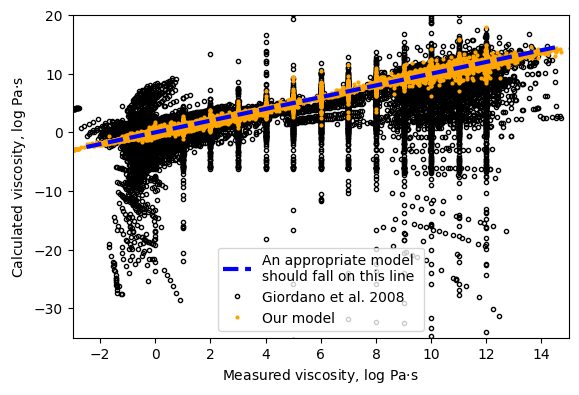

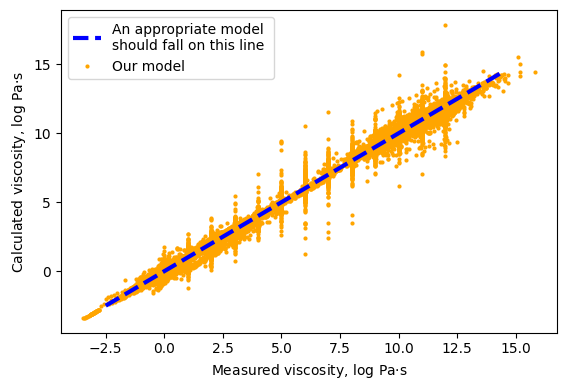

In [1]:
#!/usr/bin/env python
# coding: utf-8
# (c) Charles Le Losq, Clément Ferraina 2023-2024
# see embedded licence file

#
# Library Loading
#
import pandas as pd # manipulate dataframes
import matplotlib.pyplot as plt # plotting
import numpy as np
np.random.seed = 167 # fix random seed for reproducibility

# local imports
import gpvisc

from sklearn.preprocessing import StandardScaler
import joblib

# CPU or GPU?
device = gpvisc.get_device()

# load the datasets of gpvisc
ds = gpvisc.data_loader()

# loading the full 1 atm dataset
dataset_lp = gpvisc.chimie_control(ds.dataset_lp.copy())

# make predictions with GP model directly

# first we need to scale things
TPX_lp = gpvisc.scale_for_gaussianprocess(dataset_lp["T"],
                                          dataset_lp["T"]*0.0,
                                          dataset_lp)

# now we load the GP model and make predictions
gp_model, likelihood = gpvisc.load_gp_model(model_number=1, device=device)
GP_preds, GP_preds_std = gpvisc.predict(TPX_lp, gp_model, likelihood, device=device)

# now apply the Giordano model
# there is a G2008 function that does it all in gpvisc

# warning: we must bring together FeO and Fe2O3
dataset_lp["feo"] = dataset_lp["feo"]+2*dataset_lp["fe2o3"]
dataset_lp["fe2o3"] = 0.0 # We set Fe2O3 to 0
dataset_lp = gpvisc.chimie_control(dataset_lp)
G2008_preds = gpvisc.G2008(dataset_lp.loc[:, ['sio2', 'tio2', 'al2o3', 'feo', 'fe2o3', 'mno', 'na2o', 'k2o',
       'mgo', 'cao', 'p2o5', 'h2o','T']])

plt.figure(figsize=(6,4))
plt.plot([-2.5,14.5], [-2.5,14.5],"--", color="blue", linewidth=3.0, label="An appropriate model \nshould fall on this line", zorder=2)
plt.legend()

plt.xlabel("Measured viscosity, log Pa$\cdot$s")
plt.ylabel("Calculated viscosity, log Pa$\cdot$s")

plt.tight_layout()
#plt.savefig("./figures/Comparison_Giordano_a.pdf")

plt.plot(dataset_lp["viscosity"], G2008_preds[0],".", markerfacecolor="none", markeredgecolor="black", label="Giordano et al. 2008", zorder=0)
plt.xlim(-3,15)
plt.ylim(-35,20)

plt.legend()

#plt.savefig("./figures/Comparison_Giordano_b.pdf")

plt.plot(dataset_lp["viscosity"], GP_preds,".", markerfacecolor="orange", markeredgecolor="none", label="Our model", zorder=1)
plt.legend()
#plt.savefig("./figures/Comparison_Giordano_c.pdf")

plt.figure(figsize=(6,4))
plt.plot([-2.5,14.5], [-2.5,14.5],"--", color="blue", linewidth=3.0, label="An appropriate model \nshould fall on this line", zorder=2)
plt.legend()

plt.xlabel("Measured viscosity, log Pa$\cdot$s")
plt.ylabel("Calculated viscosity, log Pa$\cdot$s")

plt.tight_layout()
plt.plot(dataset_lp["viscosity"], GP_preds,".", markerfacecolor="orange", markeredgecolor="none", label="Our model", zorder=1)
plt.legend()
#plt.savefig("./figures/Comparison_Giordano_d.pdf")


# Case by case comparison on interesting compositions

We compare GP and G2008 for peridotite, lunar maar and CaO-Al2O3 melts at 1 atm.

### Peridotite melt

Calculation iron redox...


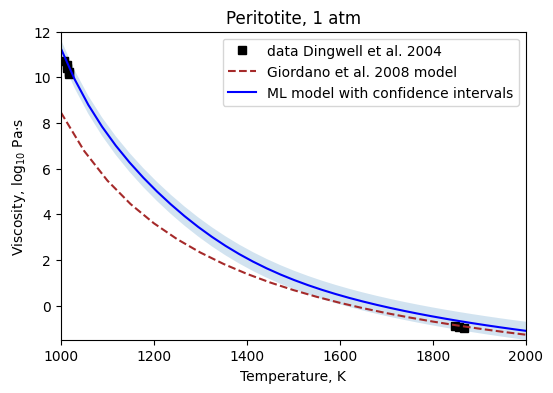

In [2]:
dataset_peridotite = ds.dataset_lp.loc[(ds.dataset_lp.Name_publi=="Pr"),:].reset_index()

T_interest = np.arange(1000,3000,50).reshape(-1,1)

X_peridotite = gpvisc.generate_query_single(sio2=dataset_peridotite.loc[0, "sio2"],
                                     tio2=dataset_peridotite.loc[0, "tio2"],
                                     al2o3=dataset_peridotite.loc[0, "al2o3"],
                                     feo=dataset_peridotite.loc[0, "fe2o3"],
                                     mno=dataset_peridotite.loc[0, "mno"],
                                     na2o=dataset_peridotite.loc[0, "na2o"],
                                     k2o=dataset_peridotite.loc[0, "k2o"],
                                     mgo=dataset_peridotite.loc[0, "mgo"],
                                     cao=dataset_peridotite.loc[0, "cao"],
                                     p2o5=dataset_peridotite.loc[0, "p2o5"],
                                     h2o=dataset_peridotite.loc[0, "h2o"],
                                     composition_mole = True,
                                     T_init = 1000.0, T_final= 60000.0,
                                     P_init = 0.0, P_final = 0.0,
                                     control_redox = True,
                                     fo2_init = np.log10(0.21), fo2_final = np.log10(0.21),
                                     nb_values = 2000,
                                     )

TPX_peridotite = gpvisc.scale_for_gaussianprocess(X_peridotite["T"], X_peridotite["P"], X_peridotite)
gp_peridotite, gp_peridotite_std = gpvisc.predict(TPX_peridotite, gp_model, likelihood, device=device)

index_Pr = np.where(dataset_lp.Name_publi=="Pr")[0]

G2008_per = gpvisc.VFT(T_interest,  
       G2008_preds[2],
       G2008_preds[3][index_Pr[0]],
       G2008_preds[4][index_Pr[0]])

plt.figure(figsize=(6,4))
plt.plot(dataset_lp.loc[index_Pr,"T"], dataset_lp.loc[index_Pr,"viscosity"], "ks", label="data Dingwell et al. 2004")
plt.plot(T_interest, G2008_per, "--", color="brown", label="Giordano et al. 2008 model")

plt.ylim(-1.5,12)
plt.xlim(1000,2000)
plt.legend()
plt.title("Peritotite, 1 atm")
plt.xlabel("Temperature, K")
plt.ylabel("Viscosity, log$_{10}$ Pa$\cdot$s")

plt.plot(X_peridotite["T"], gp_peridotite, "b-", label="ML model with confidence intervals")
plt.legend()
plt.fill_between(X_peridotite["T"], 
                 gp_peridotite-gp_peridotite_std,
                 gp_peridotite+gp_peridotite_std,
                 alpha=0.2)


### Ti-rich Lunar maar melt (Sehlke & Whittington 2016)

Calculation iron redox...


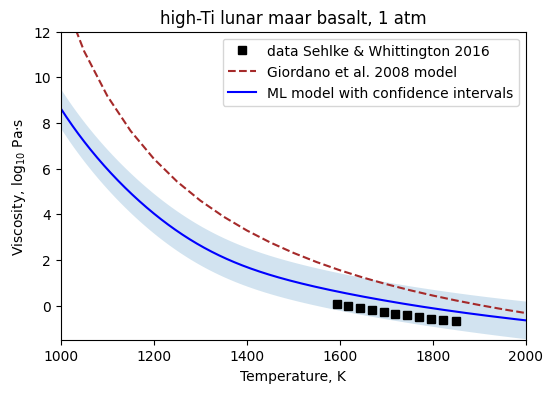

In [3]:
dataset_LM = ds.dataset_lp.loc[(ds.dataset_lp.Name_publi=="LM"),:].reset_index()

X_LM = gpvisc.generate_query_single(sio2=dataset_LM.loc[0, "sio2"],
                                     tio2=dataset_LM.loc[0, "tio2"],
                                     al2o3=dataset_LM.loc[0, "al2o3"],
                                     feo=dataset_LM.loc[0, "fe2o3"],
                                     mno=dataset_LM.loc[0, "mno"],
                                     na2o=dataset_LM.loc[0, "na2o"],
                                     k2o=dataset_LM.loc[0, "k2o"],
                                     mgo=dataset_LM.loc[0, "mgo"],
                                     cao=dataset_LM.loc[0, "cao"],
                                     p2o5=dataset_LM.loc[0, "p2o5"],
                                     h2o=dataset_LM.loc[0, "h2o"],
                                     composition_mole = True,
                                     T_init = 1000.0, T_final= 3000.0,
                                     P_init = 0.0, P_final = 0.0,
                                     control_redox = True,
                                     fo2_init = 0.67, fo2_final = 0.67,
                                     nb_values = 3000,
                                     )

TPX_LM = gpvisc.scale_for_gaussianprocess(X_LM["T"], X_LM["P"], X_LM)
gp_LM, gp_LM_std = gpvisc.predict(TPX_LM, gp_model, likelihood, device=device)

index_LM = np.where(dataset_lp.Name_publi=="LM")[0]

G2008_LM = gpvisc.VFT(T_interest,  
       G2008_preds[2],
       G2008_preds[3][index_LM[0]],
       G2008_preds[4][index_LM[0]])


plt.figure(figsize=(6,4))
plt.plot(dataset_lp.loc[index_LM,"T"], dataset_lp.loc[index_LM,"viscosity"], "ks", label="data Sehlke & Whittington 2016")
plt.plot(T_interest, G2008_LM, "--", color="brown", label="Giordano et al. 2008 model")
#plt.plot(dataset_lp.loc[index_Pr,"T"], GP_preds.numpy()[index_Pr], "bx")
plt.ylim(-1.5,12)
plt.xlim(1000,2000)
plt.legend()
plt.title("high-Ti lunar maar basalt, 1 atm")
plt.xlabel("Temperature, K")
plt.ylabel("Viscosity, log$_{10}$ Pa$\cdot$s")

plt.plot(X_LM["T"], gp_LM, "b-", label="ML model with confidence intervals")
plt.legend()
plt.fill_between(X_LM["T"], 
                 gp_LM - gp_LM_std*2,
                 gp_LM + gp_LM_std*2,
                 alpha=0.2)

### Calcium aluminate melt (Ca0.39)

/tmp/ipykernel_2520265/3145800529.py:42: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  plt.fill_between(X_CA["T"].ravel(),


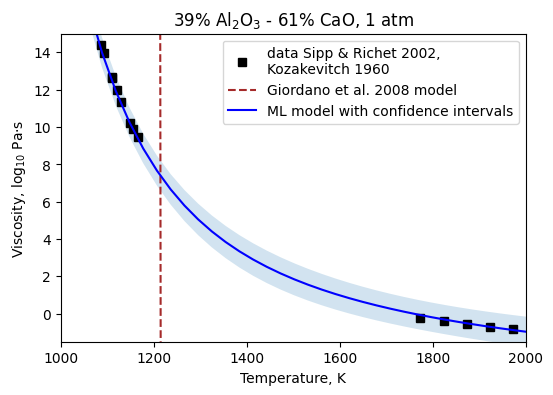

In [4]:
dataset_CA = ds.dataset_lp.loc[(ds.dataset_lp.Name_publi=="Ca0.39")|(ds.dataset_lp.Name_publi=="ACS-18"),:].reset_index()

X_CA = gpvisc.generate_query_single(sio2=dataset_CA.loc[0, "sio2"],
                                     tio2=dataset_CA.loc[0, "tio2"],
                                     al2o3=dataset_CA.loc[0, "al2o3"],
                                     feo=dataset_CA.loc[0, "fe2o3"],
                                     mno=dataset_CA.loc[0, "mno"],
                                     na2o=dataset_CA.loc[0, "na2o"],
                                     k2o=dataset_CA.loc[0, "k2o"],
                                     mgo=dataset_CA.loc[0, "mgo"],
                                     cao=dataset_CA.loc[0, "cao"],
                                     p2o5=dataset_CA.loc[0, "p2o5"],
                                     h2o=dataset_CA.loc[0, "h2o"],
                                     composition_mole = True,
                                     T_init = 1000.0, T_final= 60000.0,
                                     P_init = 0.0, P_final = 0.0,
                                     nb_values = 2000,
                                     )

TPX_CA = gpvisc.scale_for_gaussianprocess(X_CA["T"], X_CA["P"], X_CA)
gp_CA, gp_CA_std = gpvisc.predict(TPX_CA, gp_model, likelihood, device=device)

index_CA = np.where((ds.dataset_lp.Name_publi=="Ca0.39")|(ds.dataset_lp.Name_publi=="ACS-18"))[0]

G2008_CA = gpvisc.VFT(T_interest,  
       G2008_preds[2],
       G2008_preds[3][index_CA[0]],
       G2008_preds[4][index_CA[0]])

plt.figure(figsize=(6,4))
plt.plot(dataset_lp.loc[index_CA,"T"], dataset_lp.loc[index_CA,"viscosity"], "ks", label="data Sipp & Richet 2002, \nKozakevitch 1960")
plt.plot(T_interest, G2008_CA, "--", color="brown", label="Giordano et al. 2008 model")
plt.ylim(-1.5,15)
plt.xlim(1000,2000)
plt.legend()
plt.title("39% Al$_2$O$_3$ - 61% CaO, 1 atm")
plt.xlabel("Temperature, K")
plt.ylabel("Viscosity, log$_{10}$ Pa$\cdot$s")

plt.plot(X_CA["T"], gp_CA, "b-", label="ML model with confidence intervals")
plt.legend()
plt.fill_between(X_CA["T"].ravel(), 
                 gp_CA - 2*gp_CA_std,
                 gp_CA + 2*gp_CA_std,
                 alpha=0.2)


### Quick final visualization of the three predictions against measurements.

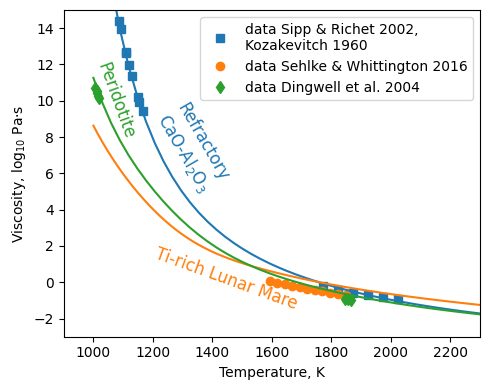

In [5]:
plt.figure(figsize=(5,4))
plt.plot(dataset_lp.loc[index_CA,"T"], dataset_lp.loc[index_CA,"viscosity"], "s", label="data Sipp & Richet 2002, \nKozakevitch 1960")
plt.plot(dataset_lp.loc[index_LM,"T"], dataset_lp.loc[index_LM,"viscosity"], "o", label="data Sehlke & Whittington 2016")
plt.plot(dataset_lp.loc[index_Pr,"T"], dataset_lp.loc[index_Pr,"viscosity"], "d", label="data Dingwell et al. 2004")
plt.legend()

plt.plot(X_CA["T"], gp_CA, "-",color="C0" , label="ML model with confidence intervals")
plt.plot(X_LM["T"], gp_LM, "-",color="C1" , label="ML model with confidence intervals")
plt.plot(X_peridotite["T"], gp_peridotite, "-",color="C2" , label="ML model with confidence intervals")

plt.ylim(-3.0,15)
plt.xlim(900,2300)

plt.annotate("Peridotite", xy=(1000,8), xycoords="data",
             fontsize=12, color="C2", rotation=290)
plt.annotate("Ti-rich Lunar Mare", xy=(1200,-1.5), xycoords="data",
             fontsize=12, color="C1", rotation=340)
plt.annotate("Refractory\nCaO-Al$_2$O$_3$", xy=(1200,5), xycoords="data",
             fontsize=12, color="C0", rotation=300)

plt.xlabel("Temperature, K")
plt.ylabel("Viscosity, log$_{10}$ Pa$\cdot$s")
plt.tight_layout()
